## Previsão Aliens

<h2>Imports</h2>

In [23]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

<h2>Loading Data</h2>

In [24]:
raw_ts = pd.read_csv(
    'ufo_sightings_scrubbed.csv',
    usecols=['datetime'],
    index_col='datetime',
    parse_dates=['datetime'],
    date_format='%Y-%m-%d %H:%M:%S'
)

<h2>Transforming Data</h2>

In [25]:
ts = raw_ts.resample('ME').size()

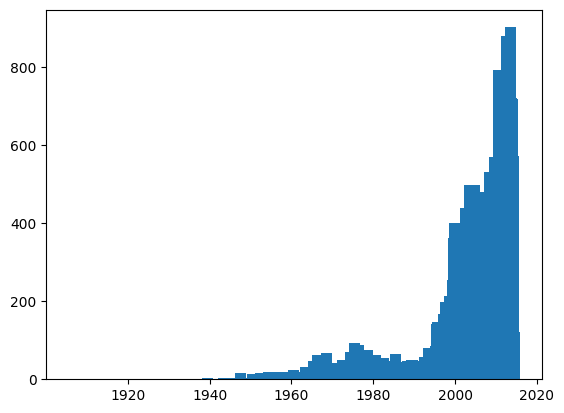

<Figure size 6400x800 with 0 Axes>

In [26]:
plt.bar(ts.index, ts.values, width=1000)
plt.figure(figsize=(64,8))
plt.show()

## ACF e PACF

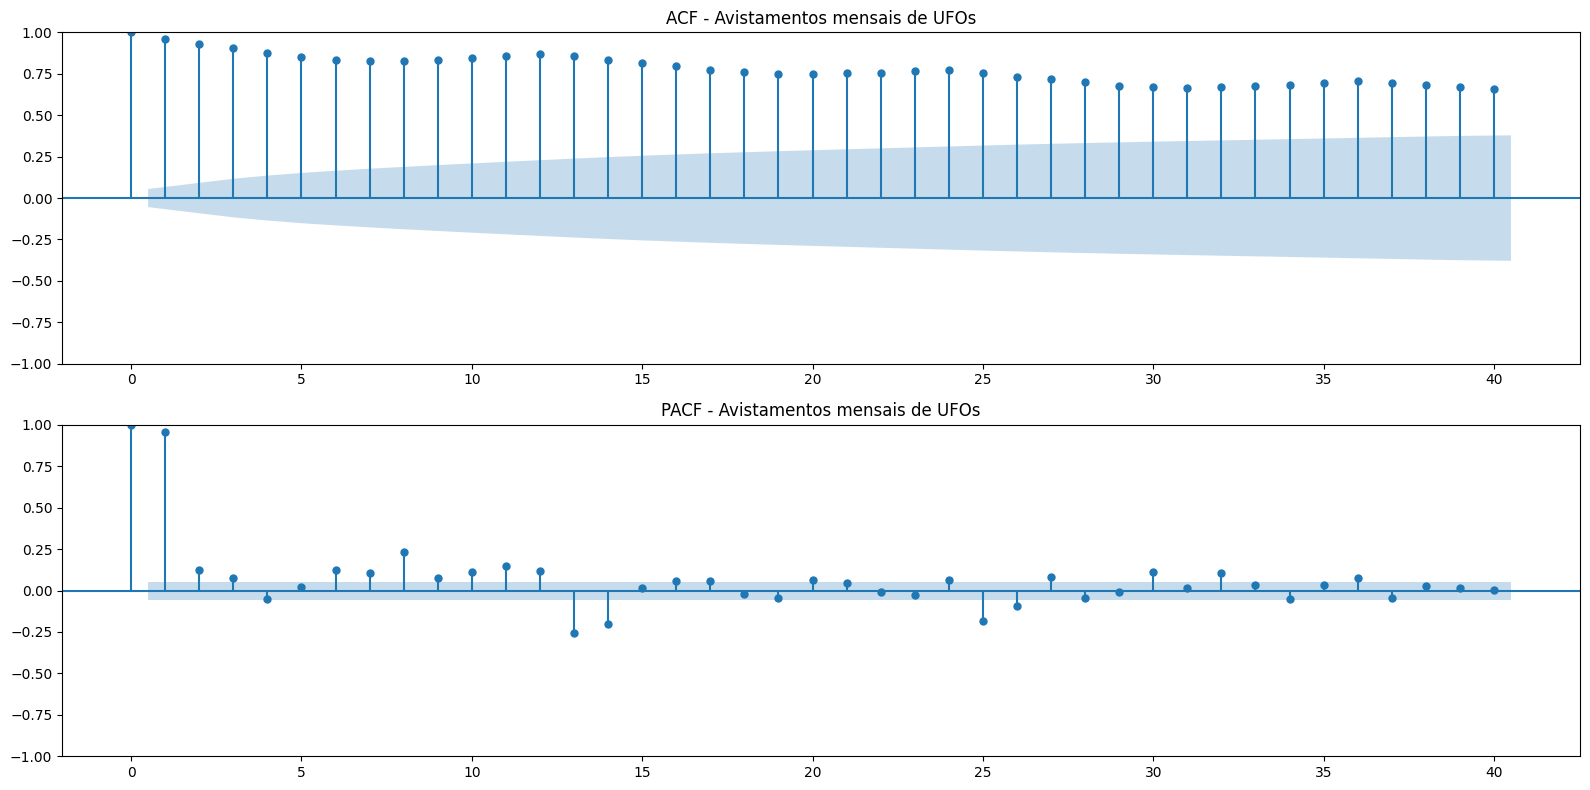

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(16, 8))

plot_acf(ts, lags=40, ax=axes[0], title='ACF - Avistamentos mensais de UFOs')
plot_pacf(ts, lags=40, ax=axes[1], title='PACF - Avistamentos mensais de UFOs')

plt.tight_layout()
plt.show()

## Base Models

In [28]:
import numpy as np
from sklearn.metrics import mean_absolute_error

def base_model_media_historica(serie):
    return pd.Series(serie.mean(), index=serie.index)

def base_model_media_acumulada(serie):
    previsao = [np.nan] + [serie.iloc[:i].mean() for i in range(1, len(serie))]
    return pd.Series(previsao, index=serie.index)

def base_model_sma(serie, k):
    return serie.rolling(window=k).mean().shift(1)

def base_model_ema(serie, alpha):
    return serie.ewm(alpha=alpha, adjust=False).mean().shift(1)

def base_model_taxa_variacao(serie, k):
    previsoes, indices = [], []
    for i in range(k, len(serie) - 1):
        va, vp = serie.iloc[i], serie.iloc[i - k]
        if vp == 0:
            continue
        previsoes.append(va * (1 + (va - vp) / vp))
        indices.append(serie.index[i + 1])
    return pd.Series(previsoes, index=indices)

def base_model_seasonal_naive(serie, s):
    return serie.shift(s)

def base_model_delta(serie, k):
    previsoes, indices = [], []
    for i in range(k, len(serie) - 1):
        va, vp = serie.iloc[i], serie.iloc[i - k]
        previsoes.append(va + (va - vp) / k)
        indices.append(serie.index[i + 1])
    return pd.Series(previsoes, index=indices)


## Split Treino/Teste

In [29]:
# últimos 12 meses para teste, restante para treino
ts_teste  = ts[-12:]
ts_treino = ts[:-12]

print(f"Treino: {len(ts_treino)} meses "
      f"({ts_treino.index[0].strftime('%Y-%m')} a {ts_treino.index[-1].strftime('%Y-%m')})")
print(f"Teste:  {len(ts_teste)} meses "
      f"({ts_teste.index[0].strftime('%Y-%m')} a {ts_teste.index[-1].strftime('%Y-%m')})")


Treino: 1279 meses (1906-11 a 2013-05)
Teste:  12 meses (2013-06 a 2014-05)


## Previsão dos 12 Meses de Teste

In [30]:
import warnings
warnings.filterwarnings('ignore')

# ── tuning interno: seleciona o melhor hiperparâmetro por modelo no treino ──
_tuning = []
for k in range(1, len(ts_treino) // 4 + 1):
    p = base_model_sma(ts_treino, k).dropna()
    _tuning.append(('SMA', k, mean_absolute_error(ts_treino[p.index], p)))
for a in np.round(np.arange(0.1, 1.0, 0.1), 2):
    p = base_model_ema(ts_treino, a).dropna()
    _tuning.append(('EMA', a, mean_absolute_error(ts_treino[p.index], p)))
for k in range(1, len(ts_treino) // 4 + 1):
    p = base_model_taxa_variacao(ts_treino, k)
    _tuning.append(('Taxa Variacao', k, mean_absolute_error(ts_treino[p.index], p)))
for s in [3, 6, 12, 24]:
    p = base_model_seasonal_naive(ts_treino, s).dropna()
    _tuning.append(('Seasonal Naive', s, mean_absolute_error(ts_treino[p.index], p)))
for k in range(1, len(ts_treino) // 4 + 1):
    p = base_model_delta(ts_treino, k)
    _tuning.append(('Delta', k, mean_absolute_error(ts_treino[p.index], p)))

_df = pd.DataFrame(_tuning, columns=['modelo', 'hiperparametro', 'mae_treino'])
melhores_hiperparametros = {}
for m in ['SMA', 'EMA', 'Taxa Variacao', 'Seasonal Naive', 'Delta']:
    sub = _df[_df['modelo'] == m]
    melhores_hiperparametros[m] = sub.loc[sub['mae_treino'].idxmin(), 'hiperparametro']

# ── funções de previsão 1 passo à frente ─────────────────────────────────────
def _prever_media_historica(historico, media_fixa):
    return media_fixa

def _prever_media_acumulada(historico):
    return historico.mean()

def _prever_sma(historico, k):
    return historico.iloc[-k:].mean() if len(historico) >= k else historico.mean()

def _prever_ema(historico, alpha):
    return historico.ewm(alpha=alpha, adjust=False).mean().iloc[-1]

def _prever_taxa_variacao(historico, k):
    if len(historico) <= k:
        return historico.mean()
    va, vp = historico.iloc[-1], historico.iloc[-1 - k]
    if vp == 0:
        return va
    return va * (1 + (va - vp) / vp)

def _prever_seasonal_naive(historico, s):
    return historico.iloc[-s] if len(historico) >= s else historico.mean()

def _prever_delta(historico, k):
    if len(historico) <= k:
        return historico.mean()
    va, vp = historico.iloc[-1], historico.iloc[-1 - k]
    return va + (va - vp) / k

# ── previsão recursiva: 12 meses à frente sem usar dados reais do teste ──────
media_fixa = ts_treino.mean()

modelos_recursivos = {
    'Media Historica': lambda h: _prever_media_historica(h, media_fixa),
    'Media Acumulada': lambda h: _prever_media_acumulada(h),
    'SMA':             lambda h: _prever_sma(h, int(melhores_hiperparametros['SMA'])),
    'EMA':             lambda h: _prever_ema(h, melhores_hiperparametros['EMA']),
    'Taxa Variacao':   lambda h: _prever_taxa_variacao(h, int(melhores_hiperparametros['Taxa Variacao'])),
    'Seasonal Naive':  lambda h: _prever_seasonal_naive(h, int(melhores_hiperparametros['Seasonal Naive'])),
    'Delta':           lambda h: _prever_delta(h, int(melhores_hiperparametros['Delta'])),
}

previsoes_teste = pd.DataFrame(index=ts_teste.index)
previsoes_teste['real'] = ts_teste.values

for nome, func in modelos_recursivos.items():
    historico = ts_treino.copy()
    prevs = []
    for data in ts_teste.index:
        p = func(historico)
        prevs.append(p)
        historico = pd.concat([historico, pd.Series([p], index=[data])])
    previsoes_teste[nome] = prevs

print(previsoes_teste.to_string())


            real  Media Historica  Media Acumulada    SMA         EMA  Taxa Variacao  Seasonal Naive       Delta
datetime                                                                                                        
2013-06-30   582        56.997654        56.997654  486.0  453.617686     608.752577             695  494.458333
2013-07-31   902        56.997654        56.997654  486.0  453.617686     762.509672             880  499.477431
2013-08-31   842        56.997654        56.997654  486.0  453.617686     955.102321             827  490.497323
2013-09-30   717        56.997654        56.997654  486.0  453.617686    1196.339505             695  485.976379
2013-10-31   720        56.997654        56.997654  486.0  453.617686    1498.507730             620  485.267061
2013-11-30   719        56.997654        56.997654  486.0  453.617686    1876.996796             719  480.903189
2013-12-31   690        56.997654        56.997654  486.0  453.617686    2351.083616            

## Métricas de Erro no Teste

In [31]:
from sklearn.metrics import mean_squared_error

nomes_modelos = ['Media Historica', 'Media Acumulada', 'SMA', 'EMA',
                 'Taxa Variacao', 'Seasonal Naive', 'Delta']

y_real = previsoes_teste['real'].values

# avisa sobre zeros em ts_teste (MAPE indefinido nesses pontos)
zeros = (y_real == 0).sum()
if zeros:
    print(f"Atencao: {zeros} ponto(s) com valor real = 0 serao ignorados no calculo do MAPE.")

metricas_lista = []
for modelo in nomes_modelos:
    y_prev = previsoes_teste[modelo].values

    mae  = mean_absolute_error(y_real, y_prev)
    mse  = mean_squared_error(y_real, y_prev)
    rmse = np.sqrt(mse)

    # MAPE: exclui posições onde y_real == 0
    mask = y_real != 0
    mape = np.mean(np.abs((y_real[mask] - y_prev[mask]) / y_real[mask])) * 100

    metricas_lista.append({'modelo': modelo, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'MAPE': mape})

metricas_teste = (pd.DataFrame(metricas_lista)
                    .sort_values('MAE')
                    .reset_index(drop=True))

print(metricas_teste.to_string(index=False))

# melhor modelo segundo o MAE
melhor_modelo_nome = metricas_teste.iloc[0]['modelo']
melhor_modelo_mae  = float(metricas_teste.iloc[0]['MAE'])
print(f"\nMelhor modelo: {melhor_modelo_nome}  |  MAE = {melhor_modelo_mae:.2f}")


         modelo         MAE          MSE        RMSE       MAPE
 Seasonal Naive  122.833333 2.760717e+04  166.154045  40.960090
          Delta  200.674880 5.585044e+04  236.326983  48.572021
            SMA  202.166667 5.667600e+04  238.067217  48.625300
            EMA  223.088209 6.635990e+04  257.604150  49.698305
Media Historica  562.335679 3.551196e+05  595.919154  87.867754
Media Acumulada  562.335679 3.551196e+05  595.919154  87.867754
  Taxa Variacao 2198.915881 9.668040e+06 3109.347168 781.727148

Melhor modelo: Seasonal Naive  |  MAE = 122.83


## Visualização

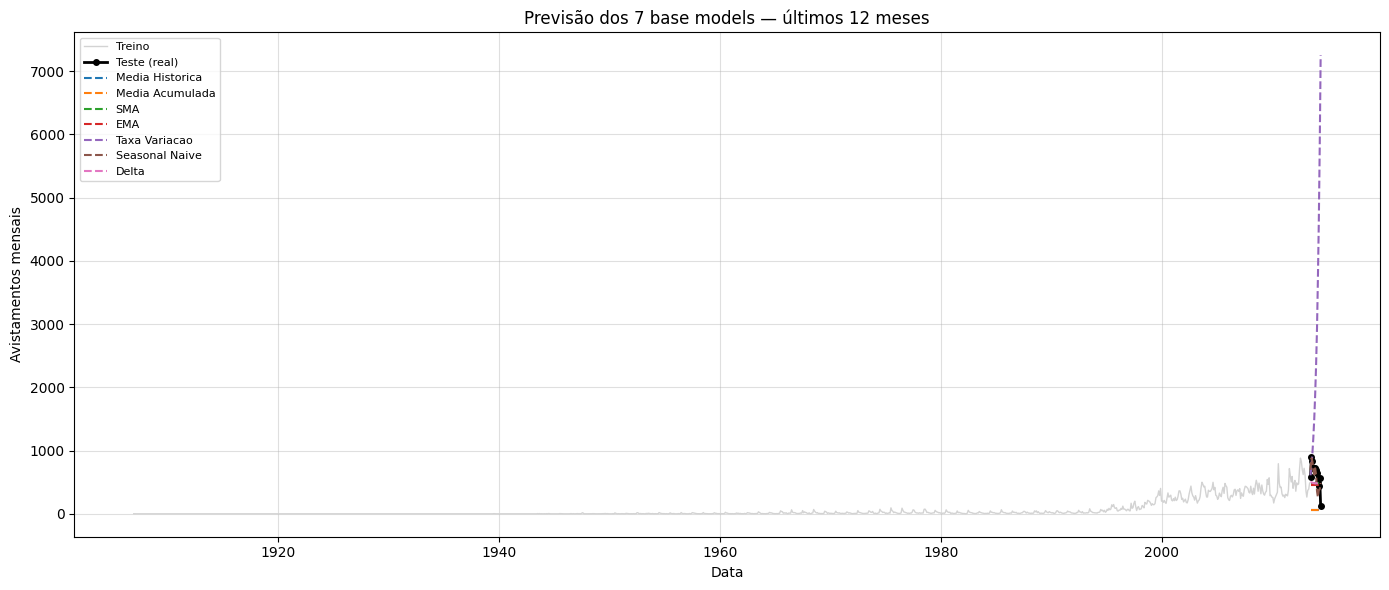

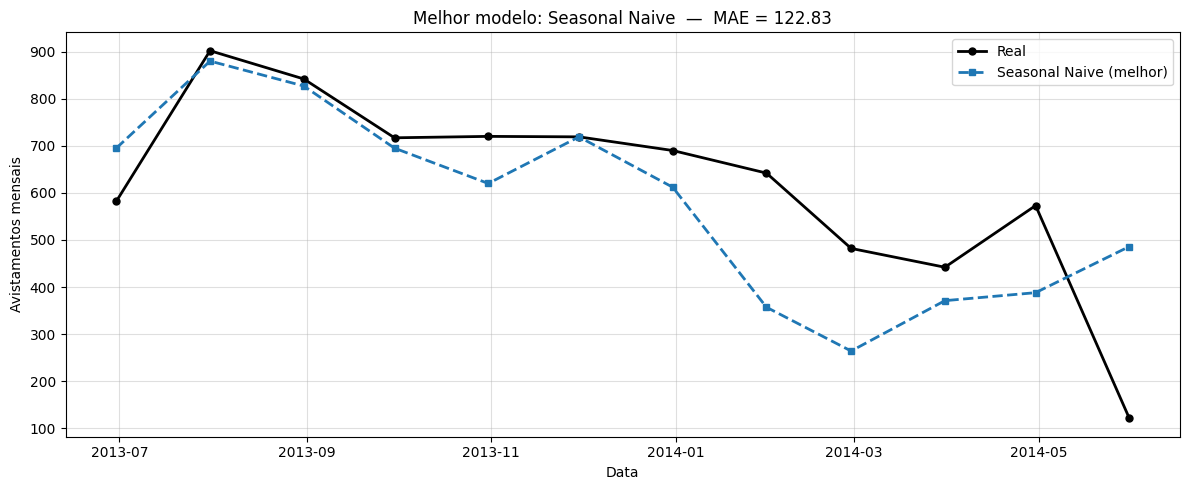

In [32]:
cores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
         '#9467bd', '#8c564b', '#e377c2']

# ── Gráfico 1: todos os modelos ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(ts_treino.index, ts_treino.values,
        color='lightgray', linewidth=1.0, label='Treino')
ax.plot(ts_teste.index, ts_teste.values,
        color='black', linewidth=2, marker='o', markersize=4, label='Teste (real)')

for i, modelo in enumerate(nomes_modelos):
    ax.plot(previsoes_teste.index, previsoes_teste[modelo].values,
            color=cores[i], linestyle='--', linewidth=1.5, label=modelo)

ax.set_title('Previsão dos 7 base models — últimos 12 meses')
ax.set_xlabel('Data')
ax.set_ylabel('Avistamentos mensais')
ax.legend(loc='upper left', fontsize=8)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# ── Gráfico 2: somente o melhor modelo ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(12, 5))

ax2.plot(ts_teste.index, ts_teste.values,
         color='black', linewidth=2, marker='o', markersize=5, label='Real')
ax2.plot(previsoes_teste.index, previsoes_teste[melhor_modelo_nome].values,
         color='#1f77b4', linestyle='--', linewidth=2, marker='s', markersize=5,
         label=f'{melhor_modelo_nome} (melhor)')

ax2.set_title(f'Melhor modelo: {melhor_modelo_nome}  —  MAE = {melhor_modelo_mae:.2f}')
ax2.set_xlabel('Data')
ax2.set_ylabel('Avistamentos mensais')
ax2.legend()
ax2.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()


## Relatório Final

O modelo vencedor segundo o MAE foi identificado na célula anterior. Cabe agora discutir o que
esse resultado significa e se o MAE é de fato a métrica mais adequada para esta série.

O MAE trata todos os erros com o mesmo peso, o que o torna robusto a outliers: um pico
isolado de avistamentos no teste contribui para o MAE exatamente na mesma proporção que
qualquer outro mês. O MSE e o RMSE, por penalizarem erros grandes de forma quadrática,
são mais sensíveis a esses picos. Um modelo que erra feio num único mês de alta poderia
parecer melhor pelo MAE e pior pelo RMSE, dependendo de como essa discrepância se distribui
nos demais meses.

A série de avistamentos de UFOs possui concentração de registros em períodos específicos —
especialmente após os anos 2000, quando plataformas de relato online popularizaram o fenômeno —
e apresenta picos isolados que se comportam como outliers no sentido estatístico. Nesse contexto,
o RMSE é mais informativo do que o MAE como critério de seleção de modelo: errar feio nos
meses de pico tem consequências práticas (subestimação de demanda por investigação, por exemplo)
que o MAE dilui na média. Por outro lado, se o objetivo for apenas ter uma previsão "razoável"
para todos os meses com igual importância, o MAE é uma escolha defensável.

O MAPE complementa a análise ao expressar o erro em termos relativos (percentuais), facilitando
a comparação entre períodos de baixa e alta actividade. Porém, ele se torna problemático quando
a série tem valores próximos de zero, situação que pode ocorrer nos primeiros anos do dataset.

Em resumo, para esta série específica, o RMSE seria a métrica primária mais recomendada caso
o objetivo seja modelar bem os episódios de alta. O MAE é preferível quando todos os erros
devem ter o mesmo peso e a robustez a outliers é desejada. O modelo selecionado pelo MAE
pode ou não coincidir com o melhor pelo RMSE — as métricas detalhadas em `metricas_teste`
permitem fazer essa comparação diretamente.
